In [1]:
import json
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import os
import pickle
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

# For embeddings and similarity computation
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    print("Required libraries imported successfully!")
except ImportError as e:
    print(f"Missing library: {e}")
    print("Please install with: pip install sentence-transformers scikit-learn networkx")

np.random.seed(42)

Required libraries imported successfully!


In [2]:
from scipy.sparse import find, csr_matrix
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import norm
from IPython.core.display import HTML

# des options permettent de limiter (ou non) le nombre de lignes/colonnes affichées
# par exemple :
# pd.set_option('display.max_rows', None)

# cette fonction permet d'afficher une "jolie" représentation du vecteur v
# ARGS :
#   v : le vecteur à afficher (par ex. une ligne de la matrice X)
#   features : le vocabulaire
#   top_n : le nombre de mots maximum à afficher
def print_feats(v, features, top_n = 30):
    _, ids, values = find(v)
    feats = [(ids[i], values[i], features[ids[i]]) for i in range(len(list(ids)))]
    top_feats = sorted(feats, key=lambda x: x[1], reverse=True)[0:top_n]
    return pd.DataFrame({"word" : [t[2] for t in top_feats], "value": [t[1] for t in top_feats]})   

# fonction qui permet d'afficher plusieurs tables pandas côte à côte (c'est cadeau)
def display_side_by_side(dfs:list, captions:list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += "&emsp;"
        #output += "\xa0\xa0\xa0"
    display(HTML(output))

In [3]:
def load_corpus(file_path: str) -> Dict[str, Dict]:
    """
    Load corpus data from JSONL file.
    Returns dictionary mapping document IDs to document data.
    """
    corpus = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():  # éviter les lignes vides
                obj = json.loads(line)
                corpus[obj["_id"]] = obj
    return corpus


def load_queries(file_path: str) -> Dict[str, Dict]:
    """
    Load query data from JSONL file.
    Returns dictionary mapping query IDs to query data.
    """
    queries = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                queries[obj["_id"]] = obj
    return queries


def load_qrels(file_path: str):
    """
    Load relevance judgments (TSV).
    Returns dict: query_id -> {doc_id: score}
    """
    qrels = {}
    with open(file_path, "r", encoding="utf-8") as f:
        next(f)  # sauter la ligne d'entête

        for line in f:
            if not line.strip():
                continue

            qid, docid, score = line.strip().split('\t')
            score = int(score)

            if qid not in qrels:
                qrels[qid] = {}

            qrels[qid][docid] = score

    return qrels

In [4]:
# Load the dataset
print("Loading dataset...")
corpus = load_corpus('corpus.jsonl')
queries = load_queries('queries.jsonl')
qrels_valid = load_qrels('valid.tsv')


print(f"Loaded {len(corpus)} documents in corpus")
print(f"Loaded {len(queries)} queries")
print(f"Loaded relevance for {len(qrels_valid)} queries (dataset)")

Loading dataset...
Loaded 25657 documents in corpus
Loaded 1000 queries
Loaded relevance for 700 queries (dataset)


2. Exploration des données et premier encodage

2.1 Statistiques simples sur les données

In [5]:
import random
from collections import Counter

print("Taille du corpus :", len(corpus))
print("Nombre de requêtes :", len(queries))
print("Nombre de requêtes avec jugements (valid) :", len(qrels_valid))

# Nombre total de paires requête / document
nb_pairs = sum(len(cands) for cands in qrels_valid.values())
print("Nombre total de paires requête-document :", nb_pairs)

# Distribution des scores (pertinent = 1, non pertinent = 0)
all_scores = [score for cand_scores in qrels_valid.values() for score in cand_scores.values()]
score_counts = Counter(all_scores)

nb_pos = score_counts.get(1, 0)
nb_neg = score_counts.get(0, 0)

print("Nombre de documents pertinents   :", nb_pos)
print("Nombre de documents non pertinents :", nb_neg)
print("Proportion de pertinents :", nb_pos / nb_pairs if nb_pairs > 0 else 0)

# Statistiques par requête : combien de positifs / négatifs en moyenne
nb_pos_par_q = [sum(1 for s in cand_scores.values() if s == 1) for cand_scores in qrels_valid.values()]
nb_neg_par_q = [sum(1 for s in cand_scores.values() if s == 0) for cand_scores in qrels_valid.values()]

print("\nMoyenne de documents pertinents par requête :", np.mean(nb_pos_par_q))
print("Moyenne de documents non pertinents par requête :", np.mean(nb_neg_par_q))
print("Min / Max pertinents par requête :", np.min(nb_pos_par_q), "/", np.max(nb_pos_par_q))

Taille du corpus : 25657
Nombre de requêtes : 1000
Nombre de requêtes avec jugements (valid) : 700
Nombre total de paires requête-document : 20950
Nombre de documents pertinents   : 3450
Nombre de documents non pertinents : 17500
Proportion de pertinents : 0.16467780429594273

Moyenne de documents pertinents par requête : 4.928571428571429
Moyenne de documents non pertinents par requête : 25.0
Min / Max pertinents par requête : 2 / 5


2.2 Exemple de requête + candidats positifs / négatifs

In [6]:
# On prend une requête au hasard parmi celles qui ont des jugements
example_qid = random.choice(list(qrels_valid.keys()))
example_query = queries.get(example_qid, {})

print("=== Exemple de requête ===")
print("Query ID :", example_qid)
print("Titre de la requête :", example_query.get("title", "(pas de titre)"))
print("Texte de la requête :", example_query.get("text", "")[:300], "...\n")

# Séparation des candidats pertinents / non pertinents
cand_scores = qrels_valid[example_qid]
pos_cands = [docid for docid, s in cand_scores.items() if s == 1]
neg_cands = [docid for docid, s in cand_scores.items() if s == 0]

print(f"Nombre de candidats pertinents (score=1) : {len(pos_cands)}")
print(f"Nombre de candidats non pertinents (score=0) : {len(neg_cands)}\n")

print("=== Titres de quelques candidats positifs ===")
for docid in pos_cands[:5]:
    doc = corpus.get(docid, {})
    print(f"- {docid} :: {doc.get('title', '(pas de titre)')}")

print("\n=== Titres de quelques candidats négatifs ===")
for docid in neg_cands[:5]:
    doc = corpus.get(docid, {})
    print(f"- {docid} :: {doc.get('title', '(pas de titre)')}")

=== Exemple de requête ===
Query ID : a91eca9d11755108c8c1a4354ed5b6c5a89ca4f8
Titre de la requête : (pas de titre)
Texte de la requête : FingerCode: A Filterbank for Fingerprint Representation and Matching ...

Nombre de candidats pertinents (score=1) : 5
Nombre de candidats non pertinents (score=0) : 25

=== Titres de quelques candidats positifs ===
- 6513888c5ef473bdbb3167c7b52f0985be071f7a :: Complete discrete 2-D Gabor transforms by neural networks for image analysis and compression
- 4d899ebf7a3004fe550842830f06b4600d9c6230 :: The theory of signal detectability
- 0be360a2964c4bb91aaad0cc6d1baa6639746028 :: Automatic recognition and analysis of human faces and facial expressions: a survey
- 5140f1dc83e562de0eb409385480b799e9549d54 :: Textural Features for Image Classification
- 86c9a59c7c4fcf0d10dbfdb6afd20dd3c5c1426c :: A Multichannel Approach to Fingerprint Classification

=== Titres de quelques candidats négatifs ===
- ab614b5712d41433e6341fd0eb465258f14d1f23 :: Ordered Neurons

2.3 Premier encodage : matrice Documents × Termes (CountVectorizer)

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# Liste des IDs + titres du corpus
corpus_ids = list(corpus.keys())
corpus_titles = [corpus[doc_id].get("title", "") for doc_id in corpus_ids]

# Vectorisation (sac de mots simple sur les titres)
vectorizer = CountVectorizer()  # paramètres par défaut au début
X = vectorizer.fit_transform(corpus_titles)

print("Matrice Documents x Termes construite.")
print("Nombre de documents :", X.shape[0])
print("Taille du vocabulaire :", X.shape[1])

# Vocabulaire (liste de mots)
features = vectorizer.get_feature_names_out()

Matrice Documents x Termes construite.
Nombre de documents : 25657
Taille du vocabulaire : 20075


2.4 Inspection de quelques vecteurs avec print_feats

In [8]:
# Un document au hasard
idx = np.random.randint(0, X.shape[0])
doc_id = corpus_ids[idx]
v = X[idx]

print("=== Exemple de vecteur de document ===")
print("Document ID :", doc_id)
print("Titre :", corpus[doc_id].get("title", ""))
print("\nMots non nuls les plus importants dans ce document :")
print(print_feats(v, features, top_n=20))

=== Exemple de vecteur de document ===
Document ID : ae612863710d1cab475c7dd677d1970294f18abd
Titre : Measuring and Analyzing Write Amplification Characteristics of Solid State Disks

Mots non nuls les plus importants dans ce document :
              word  value
0    amplification      1
1        analyzing      1
2              and      1
3  characteristics      1
4            disks      1
5        measuring      1
6               of      1
7            solid      1
8            state      1
9            write      1


2.5 Distribution des mots les plus fréquents

In [9]:
# Somme des occurrences par colonne (sur tous les documents)
word_counts = np.asarray(X.sum(axis=0)).ravel()  # shape = (vocab_size,)

# On réutilise print_feats avec un "vecteur global"
from scipy.sparse import csr_matrix
v_global = csr_matrix(word_counts)

top_words_df = print_feats(v_global, features, top_n=30)
top_words_df

,word,value
0,of,8911
1,and,8551
2,for,8090
3,in,5103
4,the,4887
5,with,2647
6,on,2558
7,based,2538
8,using,2483
9,to,2261


Histogramme:

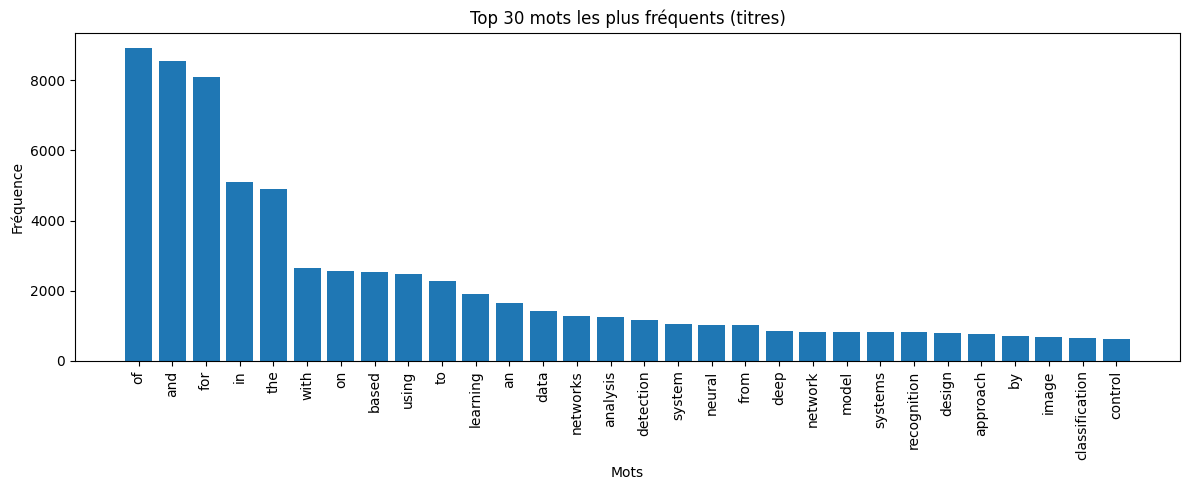

In [10]:
import matplotlib.pyplot as plt
import numpy as np

top_n = 30  # par exemple

# On récupère les top_n mots les plus fréquents
sorted_idx = np.argsort(word_counts)[::-1][:top_n]
top_words = features[sorted_idx]
top_counts = word_counts[sorted_idx]

plt.figure(figsize=(12, 5))
plt.bar(top_words, top_counts)
plt.title(f"Top {top_n} mots les plus fréquents (titres)")
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.xticks(rotation=90)  # rotation pour éviter le chevauchement
plt.tight_layout()
plt.show()

3.1 Comparer des documents avec la similarité cosinus

a) Cosinus entre deux documents du corpus

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def cosine_between_docs(i: int, j: int) -> float:
    """
    Calcule la similarité cosinus entre les documents i et j
    (indices de lignes dans la matrice X).
    """
    return float(cosine_similarity(X[i], X[j])[0, 0])

# Exemple : comparer deux documents aléatoires
i, j = np.random.randint(0, X.shape[0], size=2)

doc_i_id = corpus_ids[i]
doc_j_id = corpus_ids[j]

print("Doc i :", doc_i_id)
print("Titre i :", corpus[doc_i_id].get("title", ""))

print("\nDoc j :", doc_j_id)
print("Titre j :", corpus[doc_j_id].get("title", ""))

sim_ij = cosine_between_docs(i, j)
print(f"\nSimilarité cosinus entre i et j : {sim_ij:.4f}")

Doc i : af3c5d46ea4f54a323017c7c430e4d0cc45e4abc
Titre i : Secure and anonymous decentralized Bitcoin mixing

Doc j : 892c22460a1ef1da7d10d1cf007ff46c6c080f18
Titre j : Generating Haptic Textures with a Vibrotactile Actuator

Similarité cosinus entre i et j : 0.0000


b) Comparer un document avec plusieurs autres

Par exemple : document i vs 5 autres.

In [12]:
i = np.random.randint(0, X.shape[0])
doc_i_id = corpus_ids[i]
print("Document de référence :", doc_i_id)
print("Titre :", corpus[doc_i_id].get("title", ""), "\n")

for _ in range(5):
    j = np.random.randint(0, X.shape[0])
    if j == i:
        continue
    doc_j_id = corpus_ids[j]
    sim_ij = cosine_between_docs(i, j)
    print(f"[cos={sim_ij:.3f}] {doc_j_id} :: {corpus[doc_j_id].get('title', '')}")

Document de référence : 585706dc56e146c8fb42228fc5cbe1de0bb0a69d
Titre : CIL: Intermediate Language and Tools for Analysis and Transformation of C Programs 

[cos=0.000] 5776d0fea69d826519ee3649f620e8755a490efe :: Lifelong Machine Learning Systems: Beyond Learning Algorithms
[cos=0.167] 36c2cafdf3a0d39931e3ee46d7665270fca42350 :: Robust motion detection using histogram of oriented gradients for illumination variations
[cos=0.080] 029ec0d53785eaf719632f5aa67ae5c22689dc70 :: New circularly polarized slot radiator for substrate integrated waveguide (SIW) planar array
[cos=0.000] e2f224b84e52e3df52b91b4659ecf4deeb0d1966 :: Why it can matter more than IQ
[cos=0.113] 5db22877630e0643f9727b0a05dd69cb1eb168d6 :: Towards Operational Measures of Computer Security


c) Variante : utiliser titre + résumé

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_fulltexts = [
    (corpus[doc_id].get("title", "") + " " + corpus[doc_id].get("text", ""))
    for doc_id in corpus_ids
]

vectorizer_full = CountVectorizer()
X_full = vectorizer_full.fit_transform(corpus_fulltexts)

features_full = vectorizer_full.get_feature_names_out()

def cosine_between_docs_full(i: int, j: int) -> float:
    return float(cosine_similarity(X_full[i], X_full[j])[0, 0])

3.2 Premier moteur de recherche (bag-of-words + cosinus)

a) Fonction de recherche

In [14]:
def search_bow(query_text: str, top_k: int = 10):
    """
    Petit moteur de recherche basé sur :
    - CountVectorizer (titres)
    - similarité cosinus
    Retourne les top_k meilleurs documents.
    """
    # 1. Encoder la requête dans le même espace que les docs
    q_vec = vectorizer.transform([query_text])   # shape (1, vocab_size)

    # 2. Calculer la similarité cosinus avec tous les documents
    sims = cosine_similarity(q_vec, X)[0]        # shape (n_docs,)

    # 3. Trier par similarité décroissante
    ranked_idx = np.argsort(-sims)[:top_k]

    results = []
    for idx in ranked_idx:
        doc_id = corpus_ids[idx]
        title = corpus[doc_id].get("title", "")
        score = sims[idx]
        results.append((doc_id, score, title))
    return results

b) Tester le moteur

In [15]:
query = "sentiment analysis on financial tweets"
results = search_bow(query, top_k=10)

print("=== Requête :", query, "===\n")
for doc_id, score, title in results:
    print(f"[{score:.3f}] {doc_id} :: {title}")

=== Requête : sentiment analysis on financial tweets ===

[0.600] abbc1e4150e8fc40300d3b5d1ac05153583f4f95 :: Sentiment Analysis on Twitter Data
[0.548] 286465103c7e72c05f811e4e0c5671678b7a3db5 :: A rating approach based on sentiment analysis
[0.527] 8fb7639148d92779962be1b3b27761e9fe0a15ee :: Sentiment analysis on Twitter posts: An analysis of positive or negative opinion on GoJek
[0.507] 1b2a8dc42d6eebc937c9642799a6de87985c3da6 :: Arabic language sentiment analysis on health services
[0.496] 22031846091d6ec78b06d79ef5d61315492a92fa :: Comparison Research on Text Pre-processing Methods on Twitter Sentiment Analysis
[0.474] 7d27130a0d77fe0a89273e93a30db8f3a64b9fa3 :: Sentiment analysis and classification based on textual reviews
[0.474] 5fe44882306f659991319365a70a7b8ba5c3f7f8 :: Aspect identification and sentiment analysis based on NLP
[0.462] 5ae0ed96b0ebb7d8a03840aaf64c53b07ff0c1e7 :: News Sentiment Analysis Based on Cross-Domain Sentiment Word Lists and Content Classifiers
[0.447] 

3.3 Variantes à tester (optionnel mais conseillé)

a) Modifier les paramètres du CountVectorizer

In [16]:
vectorizer_tuned = CountVectorizer(
    stop_words="english",     # supprimer les stopwords
    max_df=0.8,               # ignorer les mots trop fréquents
    min_df=5,                 # ignorer les mots très rares
    ngram_range=(1, 2)        # unigrammes + bigrammes
)

X_tuned = vectorizer_tuned.fit_transform(corpus_titles)
features_tuned = vectorizer_tuned.get_feature_names_out()

b) Passer à TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.8,
    min_df=5
)

X_tfidf = tfidf_vectorizer.fit_transform(corpus_titles)
features_tfidf = tfidf_vectorizer.get_feature_names_out()

def search_tfidf(query_text: str, top_k: int = 10):
    q_vec = tfidf_vectorizer.transform([query_text])
    sims = cosine_similarity(q_vec, X_tfidf)[0]
    ranked_idx = np.argsort(-sims)[:top_k]

    results = []
    for idx in ranked_idx:
        doc_id = corpus_ids[idx]
        title = corpus[doc_id].get("title", "")
        score = sims[idx]
        results.append((doc_id, score, title))
    return results

Test rapide:

In [18]:
query = "sentiment analysis on financial tweets"
for doc_id, score, title in search_tfidf(query, top_k=10):
    print(f"[{score:.3f}] {doc_id} :: {title}")

[0.563] 8173411609b20d2ff2380e53573069e8aaac1b95 :: Transferring sentiment knowledge between words and tweets
[0.506] 5703defbb193df2ff616452b485b8d5f524b0cf7 :: Sentiment analysis using Telugu SentiWordNet
[0.474] 41c8ff7475225c9dfe9cedc25c038e9216345cc6 :: Hashtag recommendation for hyperlinked tweets
[0.457] 9637933765f969cda170391d95ee3ff792299665 :: Sentiment Analyzer with Rich Features for Ironic and Sarcastic Tweets
[0.442] 577f5fcadbb97d73c1a41a4fcb17873ad959319c :: CATS: Collection and Analysis of Tweets Made Simple
[0.410] 97cb3258a85a447a61e3812846f7a6e72ff3c1e1 :: Company event popularity for financial markets using Twitter and sentiment analysis
[0.405] 355f9782e9667c19144e137761a7d44977c7a5c2 :: A content analysis of depression-related tweets
[0.393] abbc1e4150e8fc40300d3b5d1ac05153583f4f95 :: Sentiment Analysis on Twitter Data
[0.393] 32e34ae2d53a1829dcfaadc1e6ce8cc9aa795152 :: Sentiment Analysis of Twitter Data
[0.375] be29cc9cd74fd7d260b4571a4b72518accae5127 :: Semisup

Partie 4

In [24]:
import os
import numpy as np
import pickle

EMB_FILE = "corpus_embeddings.npy"
IDS_FILE = "corpus_ids.pkl"
MODEL_FILE = "sentence_transformer_model_name.txt"
MODEL_NAME = "all-MiniLM-L6-v2"  # valeur par défaut

corpus_embeddings = None
corpus_ids = None

if os.path.exists(EMB_FILE) and os.path.exists(IDS_FILE):
    print("Fichiers d'embeddings trouvés, chargement...")

    corpus_embeddings = np.load(EMB_FILE)
    
    with open(IDS_FILE, "rb") as f:
        corpus_ids = pickle.load(f)

    print("Embeddings chargés, shape :", corpus_embeddings.shape)
    print("Nombre de documents :", len(corpus_ids))

    # optionnel : lire le modèle utilisé (si fichier présent)
    if os.path.exists(MODEL_FILE):
        with open(MODEL_FILE, "r", encoding="utf-8") as f:
            MODEL_NAME = f.read().strip()
        print("Modèle utilisé lors de l'encodage :", MODEL_NAME)
else:
    print("Pas de fichier d'embeddings trouvé : il faut les construire (partie 4.2).")

Fichiers d'embeddings trouvés, chargement...
Embeddings chargés, shape : (25657, 384)
Nombre de documents : 25657
Modèle utilisé lors de l'encodage : all-MiniLM-L6-v2


4.1 Choix du modèle & construction des textes à encoder

On va utiliser le modèle recommandé dans l’énoncé :
all-MiniLM-L6-v2 (rapide et généralement très correct).

On va encoder titre + résumé pour chaque article.

In [19]:
from sentence_transformers import SentenceTransformer

# Nom du modèle (téléchargé automatiquement la première fois)
MODEL_NAME = "all-MiniLM-L6-v2"

# On fixe un ordre stable des documents (important pour retrouver les bons IDs)
corpus_ids = list(corpus.keys())  # ou sorted(corpus.keys()) si tu préfères
len(corpus_ids)

25657

Construisons les textes d’entrée du modèle :

In [20]:
# Texte d'entrée pour chaque doc : titre + résumé
corpus_texts_dense = [
    (corpus[doc_id].get("title", "") + " " + corpus[doc_id].get("text", ""))
    for doc_id in corpus_ids
]

4.2 Construction des embeddings avec SentenceTransformer

In [21]:
import numpy as np

print("Chargement du modèle SentenceTransformer...")
model = SentenceTransformer(MODEL_NAME)

print("Encodage du corpus ")
corpus_embeddings = model.encode(
    corpus_texts_dense,
    batch_size=64,              
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   
)

print("Embeddings du corpus construits.")
print("Shape :", corpus_embeddings.shape)  # (nb_docs, dim_embedding)

Chargement du modèle SentenceTransformer...
Encodage du corpus 


Batches: 100%|██████████| 401/401 [17:29<00:00,  2.62s/it]


Embeddings du corpus construits.
Shape : (25657, 384)


In [22]:
import pickle
import os

EMB_FILE = "corpus_embeddings.npy"
IDS_FILE = "corpus_ids.pkl"
MODEL_FILE = "sentence_transformer_model_name.txt"

# Sauvegarde des embeddings
np.save(EMB_FILE, corpus_embeddings)
print(f"Embeddings sauvegardés dans {EMB_FILE}")

# Sauvegarde de la liste des IDs
with open(IDS_FILE, "wb") as f:
    pickle.dump(corpus_ids, f)
print(f"IDs du corpus sauvegardés dans {IDS_FILE}")

# Sauvegarde du nom du modèle (utile si tu changes plus tard de modèle)
with open(MODEL_FILE, "w", encoding="utf-8") as f:
    f.write(MODEL_NAME)
print(f"Nom du modèle sauvegardé dans {MODEL_FILE}")

Embeddings sauvegardés dans corpus_embeddings.npy
IDs du corpus sauvegardés dans corpus_ids.pkl
Nom du modèle sauvegardé dans sentence_transformer_model_name.txt


4.5 Encodage des requêtes

In [25]:
# À faire après avoir chargé / créé le modèle SentenceTransformer
model = SentenceTransformer(MODEL_NAME)

def encode_query_text(text: str) -> np.ndarray:
    """
    Encode un texte de requête (titre + éventuellement texte) en embedding dense.
    Retourne un vecteur numpy de dimension (dim_embedding,).
    """
    emb = model.encode(
        [text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    return emb[0]

Partie 5

In [28]:
import pickle
import os
import numpy as np

EMB_FILE = "corpus_embeddings.npy"
IDS_FILE = "corpus_ids.pkl"

# 1) Charger les embeddings si ce n'est pas déjà fait
if "corpus_embeddings" not in globals():
    if os.path.exists(EMB_FILE):
        corpus_embeddings = np.load(EMB_FILE)
        print("Embeddings chargés depuis", EMB_FILE, "shape:", corpus_embeddings.shape)
    else:
        raise RuntimeError("corpus_embeddings n'existe pas en mémoire et le fichier corpus_embeddings.npy n'a pas été trouvé.")

# 2) Récupérer la liste des IDs dans le même ordre
if os.path.exists(IDS_FILE):
    with open(IDS_FILE, "rb") as f:
        corpus_ids_dense = pickle.load(f)
    print("corpus_ids_dense chargé depuis", IDS_FILE, "len:", len(corpus_ids_dense))
else:
    # Si tu n'as pas sauvegardé les IDs, on suppose que tu avais utilisé corpus_ids
    if "corpus_ids" in globals():
        corpus_ids_dense = corpus_ids
        print("IDS_FILE absent, utilisation de corpus_ids comme corpus_ids_dense.")
    else:
        raise RuntimeError("Impossible de trouver corpus_ids_dense : ni fichier corpus_ids.pkl ni variable corpus_ids.")

corpus_ids_dense chargé depuis corpus_ids.pkl len: 25657


5.1 Préparer un index doc_id → index embedding

In [29]:
import numpy as np
# Mapping doc_id -> index dans corpus_embeddings
docid_to_idx = {doc_id: i for i, doc_id in enumerate(corpus_ids_dense)}
len(docid_to_idx), corpus_embeddings.shape

(25657, (25657, 384))

5.2 Fonction pour encoder le texte d’une requête

In [30]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(MODEL_NAME)

def get_query_text(qid: str) -> str:
    """
    Construit le texte de la requête à partir de queries[qid].
    Ici : titre + texte (si dispo).
    """
    q = queries[qid]
    title = q.get("title", "")
    text = q.get("text", "")
    return (title + " " + text).strip()

def encode_query_text(text: str) -> np.ndarray:
    emb = model.encode(
        [text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    return emb[0]

5.3 Moteur dense : trier les 25 candidats d’une requête

In [31]:
def search_dense_for_query(qid: str):
    """
    Moteur de recherche dense pour UNE requête :
    - encode la requête (titre + texte)
    - calcule la similarité avec les candidats de qrels_valid[qid]
    - retourne une liste triée : (doc_id, score, label)
    """
    # Texte & embedding de la requête
    q_text = get_query_text(qid)
    q_emb = encode_query_text(q_text)  # shape (dim,)

    candidates = qrels_valid[qid]  # dict doc_id -> 0/1
    results = []

    for doc_id, label in candidates.items():
        idx = docid_to_idx.get(doc_id)
        if idx is None:
            # doc candidat qui n'est pas dans le corpus_embeddings (rare mais possible)
            continue

        doc_emb = corpus_embeddings[idx]   # shape (dim,)
        # Embeddings normalisés → produit scalaire = cosinus
        score = float(np.dot(q_emb, doc_emb))
        results.append((doc_id, score, label))

    # Tri décroissant des scores
    results.sort(key=lambda x: x[1], reverse=True)
    return results

5.4 Afficher le résultat pour quelques requêtes

In [32]:
import random

def show_dense_results_for_random_query():
    qid = random.choice(list(qrels_valid.keys()))
    print("=== Query ID :", qid, "===")
    print("Titre requête :", queries[qid].get("title", ""))
    print()

    results = search_dense_for_query(qid)

    print("Top 10 candidats (score, label, titre) :\n")
    for doc_id, score, label in results[:10]:
        title = corpus.get(doc_id, {}).get("title", "(pas de titre)")
        print(f"[{score:.3f}] label={label} :: {title}")

# Exemple : lancer plusieurs fois pour voir différents cas
show_dense_results_for_random_query()

=== Query ID : 703099734f70f0cc00773ee54b4385f89afa7afe ===
Titre requête : 

Top 10 candidats (score, label, titre) :

[0.567] label=1 :: U-Net: Convolutional Networks for Biomedical Image Segmentation
[0.469] label=1 :: Efficient Piecewise Training of Deep Structured Models for Semantic Segmentation
[0.447] label=1 :: The Cityscapes Dataset for Semantic Urban Scene Understanding
[0.407] label=1 :: SegNet: A Deep Convolutional Encoder-Decoder Architecture for Image Segmentation
[0.396] label=0 :: Collaging on Internal Representations: An Intuitive Approach for Semantic Transfiguration
[0.318] label=0 :: MDig : Multi-digit Recognition using Convolutional Nerual Network on Mobile
[0.300] label=0 :: Towards deep learning with segregated dendrites
[0.283] label=0 :: Weather classification with deep convolutional neural networks
[0.235] label=0 :: Image Deblurring via Enhanced Low-Rank Prior
[0.221] label=1 :: Learning with Noisy Labels


5.5 Évaluation globale : précision, rappel, F1, AUC

On va :

Passer sur toutes les requêtes de qrels_valid.

Récupérer pour chaque paire (requête, doc candidat) :

le label (0/1),

le score dense (cosinus).

Calculer :

précision,

rappel,

F1,

AUC (ROC).

a) Récupérer tous les labels + scores

In [33]:
from tqdm import tqdm  # optionnel pour une barre de progression

all_true = []
all_scores = []

for qid in tqdm(qrels_valid.keys(), desc="Évaluation dense"):
    results = search_dense_for_query(qid)  # liste triée (doc_id, score, label)
    for doc_id, score, label in results:
        all_true.append(label)
        all_scores.append(score)

all_true = np.array(all_true)
all_scores = np.array(all_scores)

print("Nombre total de paires évaluées :", len(all_true))

Évaluation dense: 100%|██████████| 700/700 [00:15<00:00, 44.86it/s]

Nombre total de paires évaluées : 20950
